# Environment Setup & Data Ingestion Pipeline

**Purpose**  
Load the raw Halstead CSV, apply deterministic normalisation transforms, and define global constants used throughout the analysis.

**Input**  
- `halstead_results.csv` — Raw Halstead metrics dataset.

**Primary Output**  
- `df` — Analysis-ready `DataFrame`  
  - 64 rows (8 circuits × 4 SDKs × 2 conditions)  
  - 13 columns (primitive counts + derived metrics)

**Defined Constants**
- `SDK_ORDER` — Canonical SDK ordering  
- `CIRCUIT_ORDER` — Circuit ordering (increasing expected complexity)  
- `CONDITION_ORDER` — Import-condition ordering  
- `METRICS` — Target metrics: effort, volume, difficulty  
- `SDK_PALETTE` — Consistent plot colours  
- `METRIC_LABELS` — Publication-ready metric names  
- `METRIC_YLABELS` — Axis labels for figures

**Notes**
- All transformations are deterministic.
- No statistical inference is performed in this cell.
- This cell must execute before any downstream analysis.

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import pingouin as pg
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib import rcParams
from IPython.display import display


# -----------------------------------------------------------------------------
# 1. Matplotlib Runtime Configuration
# -----------------------------------------------------------------------------

rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":         10,
    "axes.titlesize":    10,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "figure.titlesize":  11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.linestyle":    ":",
    "grid.alpha":        0.45,
    "grid.color":        "#cccccc",
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})


# -----------------------------------------------------------------------------
# 2. Load Dataset
# -----------------------------------------------------------------------------

df = pd.read_csv("halstead_results.csv")


# -----------------------------------------------------------------------------
# 3. Extract SDK Identifier
# -----------------------------------------------------------------------------

df["sdk"] = df["sdk"].str.split("_").str[0]


# -----------------------------------------------------------------------------
# 4. Standardise Circuit Labels
# -----------------------------------------------------------------------------

CIRCUIT_NAME_MAP = {
    "bell":     "Bell",
    "DJ":       "DJ",
    "GHZ":      "GHZ",
    "Grover":   "Grover",
    "qaoa":     "QAOA",
    "P_ansatz": "Ansatz",
    "QFT":      "QFT",
    "teleport": "Teleport",
}

df["circuit"] = df["circuit"].replace(CIRCUIT_NAME_MAP)


# -----------------------------------------------------------------------------
# 5. Standardise SDK Labels
# -----------------------------------------------------------------------------

SDK_NAME_MAP = {
    "cirq":      "Cirq",
    "pennylane": "PennyLane",
    "qiskit":    "Qiskit",
    "qsharp":    "Q#",
}

df["sdk"] = df["sdk"].replace(SDK_NAME_MAP)


# -----------------------------------------------------------------------------
# 6. Standardise Condition Labels
# -----------------------------------------------------------------------------

DATASET_NAME_MAP = {
    "With_import":    "With import",
    "Without_import": "Without import",
}

df["dataset"] = df["dataset"].replace(DATASET_NAME_MAP)


# -----------------------------------------------------------------------------
# 7. Construct Repeated-Measures Block Identifier
# -----------------------------------------------------------------------------

df["block"] = df["circuit"] + " | " + df["dataset"]


# -----------------------------------------------------------------------------
# 8. Ordering Constants
# -----------------------------------------------------------------------------

SDK_ORDER = ["Cirq", "PennyLane", "Qiskit", "Q#"]

CIRCUIT_ORDER = [
    "Bell",
    "GHZ",
    "Ansatz",
    "QAOA",
    "QFT",
    "DJ",
    "Teleport",
    "Grover",
]

CONDITION_ORDER = ["With import", "Without import"]

METRICS = ["effort", "volume", "difficulty"]


# -----------------------------------------------------------------------------
# 9. Colour Mapping
# -----------------------------------------------------------------------------

SDK_PALETTE = {
    "Cirq":      "#0072B2",
    "PennyLane": "#D55E00",
    "Qiskit":    "#009E73",
    "Q#":        "#56B4E9",
}


# -----------------------------------------------------------------------------
# 10. Metric Label Dictionaries
# -----------------------------------------------------------------------------

METRIC_LABELS = {
    "effort":     r"Halstead Effort ($E$)",
    "volume":     r"Halstead Volume ($V$)",
    "difficulty": r"Halstead Difficulty ($D$)",
}

METRIC_YLABELS = {
    "effort":     r"Effort ($E$)",
    "volume":     r"Volume ($V$)",
    "difficulty": r"Difficulty ($D$)",
}


# -----------------------------------------------------------------------------
# 11. Balanced Design Validation
# -----------------------------------------------------------------------------

sdk_counts = df.groupby("sdk").size()

print("Observations per SDK:")
print(sdk_counts.to_string())

assert all(sdk_counts == 16), \
    f"Expected 16 observations per SDK; got: {sdk_counts.to_dict()}"

circuit_counts = df.groupby("circuit").size()

assert all(circuit_counts == 8), \
    f"Expected 8 observations per circuit; got: {circuit_counts.to_dict()}"

print(
    f"\nDataset validated — {len(df)} total observations "
    f"({len(df['circuit'].unique())} circuits × "
    f"{len(df['sdk'].unique())} SDKs × "
    f"{len(df['dataset'].unique())} conditions)"
)


# -----------------------------------------------------------------------------
# 12. Dataset Preview
# -----------------------------------------------------------------------------

display(
    df[["dataset", "circuit", "sdk", "n1", "n2",
        "N1", "N2", "vocabulary", "length",
        "volume", "difficulty", "effort"]]
    .sort_values(["dataset", "circuit", "sdk"])
    .head(12)
    .reset_index(drop=True)
)

Observations per SDK:
sdk
Cirq         16
PennyLane    16
Q#           16
Qiskit       16

Dataset validated — 64 total observations (8 circuits × 4 SDKs × 2 conditions)


,dataset,circuit,sdk,n1,n2,N1,N2,vocabulary,length,volume,difficulty,effort
0,With import,Ansatz,Cirq,12,12,64,40,24,104,476.836100,20.000000,9536.722002
1,With import,Ansatz,PennyLane,15,13,49,36,28,85,408.625168,20.769231,8486.830420
2,With import,Ansatz,Q#,15,18,64,38,33,102,514.528200,15.833333,8146.696503
3,With import,Ansatz,Qiskit,11,15,47,38,26,85,399.537376,13.933333,5566.887440
4,With import,Bell,Cirq,10,10,38,26,20,64,276.603398,13.000000,3595.844175
5,With import,Bell,PennyLane,14,11,34,25,25,59,273.987515,15.909091,4358.892287
6,With import,Bell,Q#,19,17,73,38,36,111,573.861675,21.235294,12186.121455
7,With import,Bell,Qiskit,12,12,44,31,24,75,343.872188,15.500000,5330.018907
8,With import,DJ,Cirq,11,11,76,46,22,122,544.050657,23.000000,12513.165122
9,With import,DJ,PennyLane,15,12,59,42,27,101,480.243638,26.250000,12606.395490


# Cell 2 — Descriptive Statistics

**Purpose**  
Compute and display summary statistics across SDKs, conditions, and circuits for the selected Halstead metrics.

---

## Outputs

- `desc_overall`  
  SDK-level aggregation  
  - n = 16 observations per SDK  
  - Aggregated across all circuits and both conditions  

- `desc_cond`  
  SDK × condition disaggregation  
  - n = 8 observations per cell  

- `desc_circuit`  
  Circuit-level aggregation  
  - n = 8 observations per circuit  

---

## Tables Generated

**Table 1 — By SDK**  
Mean, standard deviation, median, minimum, and maximum per metric.

**Table 2 — By SDK × Condition**  
Mean, standard deviation, and median per metric within each import condition.

**Table 3 — By Circuit**  
Mean and standard deviation per metric, ordered by predefined circuit complexity.

---

**Notes**
- All statistics are computed using the metrics defined in `METRICS`.
- Ordering is controlled by `SDK_ORDER`, `CONDITION_ORDER`, and `CIRCUIT_ORDER`.
- No inferential testing is performed in this cell.

In [3]:
# -------------------------------------------------------------------------
# Table 1 — SDK-Level Aggregation
# -------------------------------------------------------------------------
# Metrics aggregated across all circuits and both import conditions.
print("=" * 62)
print("  TABLE 1 — Descriptive Statistics by SDK  (n = 16 per SDK)")
print("=" * 62)

desc_overall = (
    df.groupby("sdk")[METRICS]
    .agg(["mean", "std", "median", "min", "max"])
    .round(3)
    .reindex(SDK_ORDER)
)

display(desc_overall)


# -------------------------------------------------------------------------
# Table 2 — SDK × Import Condition
# -------------------------------------------------------------------------
# Disaggregates metric distributions by SDK and dataset condition.
print("\n" + "=" * 65)
print("  TABLE 2 — Descriptive Statistics by SDK × Condition  (n = 8 per cell)")
print("=" * 65)

desc_cond = (
    df.groupby(["sdk", "dataset"])[METRICS]
    .agg(["mean", "std", "median"])
    .round(3)
    .reindex(SDK_ORDER, level="sdk")
    .reindex(CONDITION_ORDER, level="dataset")
)

display(desc_cond)


# -------------------------------------------------------------------------
# Table 3 — Circuit-Level Aggregation
# -------------------------------------------------------------------------
# Circuits ordered according to predefined complexity ordering.
print("\n" + "=" * 65)
print("  TABLE 3 — Descriptive Statistics by Circuit  (n = 8 per circuit)")
print("=" * 65)

desc_circuit = (
    df.groupby("circuit")[METRICS]
    .agg(["mean", "std"])
    .round(3)
    .reindex(CIRCUIT_ORDER)
)

display(desc_circuit)

  TABLE 1 — Descriptive Statistics by SDK  (n = 16 per SDK)


effort                                              volume  \
                mean        std     median       min        max     mean   
sdk                                                                        
Cirq       17699.055  17857.541  11024.944  3511.620  62754.396  566.581   
PennyLane  13876.664  11436.545  10781.328  4358.892  44572.988  473.678   
Qiskit     16358.076  13935.397  11120.506  5330.019  55243.166  504.678   
Q#         19227.225  16348.565  13495.313  6523.985  59822.725  677.879   

                                               difficulty                  \
               std   median      min       max       mean     std  median   
sdk                                                                         
Cirq       232.324  511.695  263.372  1071.725     26.064  13.784  21.500   
PennyLane  184.977  426.683  245.269   908.442     26.216   9.286  23.659   
Qiskit     180.806  460.719  279.385   895.665     28.917  14.739  25.250   
Q#         281.449  584.429  394.307  1354.458     25.028   9.849  22.753   

                           
              min     max  
sdk                        
Cirq       13.000  60.000  
PennyLane  15.909  51.818  
Qiskit     13.933  69.000  
Q#         15.833  51.000


  TABLE 2 — Descriptive Statistics by SDK × Condition  (n = 8 per cell)


effort                         volume           \
                               mean        std     median     mean      std   
sdk       dataset                                                             
Cirq      With import     17465.903  17693.352  11024.944  580.130  241.399   
          Without import  17932.207  19239.557  10818.960  553.033  238.676   
PennyLane With import     13304.140  10893.930  10510.915  492.583  193.945   
          Without import  14449.187  12682.552  11105.735  454.774  186.788   
Qiskit    With import     13792.605  10666.665   9632.388  545.726  185.376   
          Without import  18923.547  16950.259  12259.581  463.630  178.428   
Q#        With import     19493.949  15647.462  14053.557  747.618  290.867   
          Without import  18960.502  18103.250  12777.653  608.140  272.072   

                                  difficulty                  
                           median       mean     std  median  
sdk       dataset                                             
Cirq      With import     520.182     25.349  13.310  21.500  
          Without import  489.717     26.779  15.126  21.918  
PennyLane With import     444.434     24.248   8.251  22.018  
          Without import  410.447     28.184  10.384  24.923  
Qiskit    With import     506.130     22.611   9.137  19.024  
          Without import  423.733     35.223  17.062  29.000  
Q#        With import     649.110     23.346   8.173  21.471  
          Without import  512.478     26.709  11.601  24.300


  TABLE 3 — Descriptive Statistics by Circuit  (n = 8 per circuit)


effort               volume          difficulty        
               mean        std      mean      std       mean     std
circuit                                                             
Bell       6403.092   3334.914   338.508  115.922     18.269   4.630
GHZ        8267.675   2137.658   425.994   78.394     19.548   4.722
Ansatz     7777.823   1509.817   417.086   62.608     18.746   3.180
QAOA       7653.722   1009.723   412.957   67.487     18.757   2.583
QFT       14948.174   2686.994   588.051   90.219     25.550   3.669
DJ        18425.214   7296.673   618.586  193.507     29.576   6.320
Teleport  19546.928   5984.847   630.700   79.205     30.777   8.149
Grover    51299.412  10066.309  1013.750  185.116     51.227  10.119

# Cell 3 — Boxplot Visualisation

**Purpose**  
Visualise the per-SDK distribution of each Halstead metric under both import conditions using paired panel boxplots.

---

## Design

- Layout: **1 × 2 panels**
  - Panel (a): With Import  
  - Panel (b): Without Import  

- Boxplots display:
  - Interquartile range (IQR)
  - Median line
  - No fliers (outliers suppressed)

- Raw circuit observations are overlaid using strip plots.

---

## Outputs

For each metric in `METRICS`, a vector PDF is generated:

- `box_plot_effort.pdf`
- `box_plot_volume.pdf`
- `box_plot_difficulty.pdf`

---

**Notes**
- SDK ordering is controlled by `SDK_ORDER`.
- Condition ordering is controlled by `CONDITION_ORDER`.
- Colour mapping is defined by `SDK_PALETTE`.
- Each figure reflects 8 observations per SDK per condition.

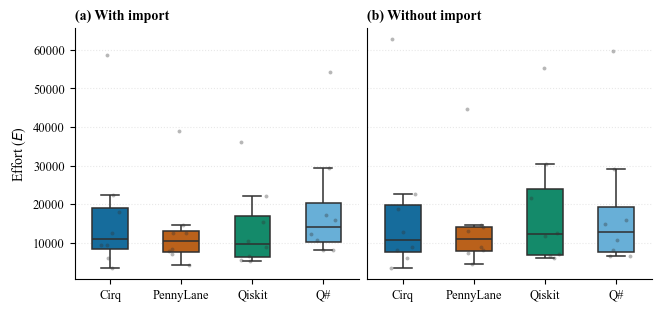

Exported: box_plot_effort.pdf


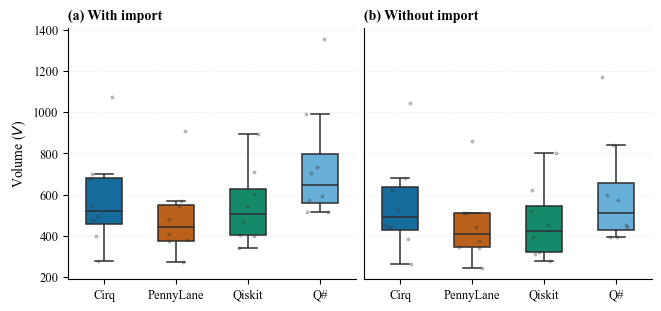

Exported: box_plot_volume.pdf


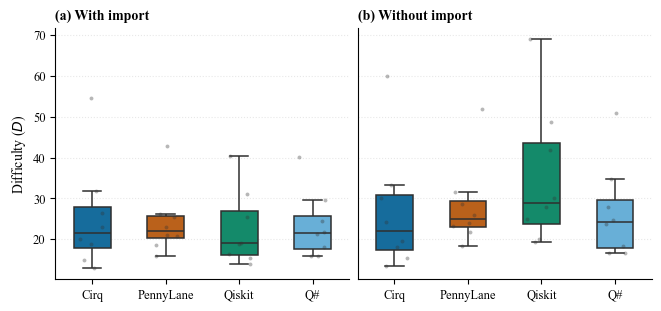

Exported: box_plot_difficulty.pdf


In [4]:
for metric in METRICS:

    # Create 1 × 2 subplot layout with shared y-axis
    fig, axes = plt.subplots(
        1, 2,
        figsize=(6.5, 3.0),
        sharey=True,
        layout="constrained",
    )

    for i, (ax, condition) in enumerate(zip(axes, CONDITION_ORDER)):

        # Subset data by condition
        subset = df[df["dataset"] == condition]

        # Boxplot layer (IQR summary; outliers suppressed)
        sns.boxplot(
            data=subset,
            x="sdk", y=metric,
            hue="sdk",
            order=SDK_ORDER,
            palette=SDK_PALETTE,
            width=0.50,
            linewidth=1.1,
            showfliers=False,
            legend=False,
            ax=ax,
            zorder=2,
        )

        # Strip plot layer (individual observations)
        sns.stripplot(
            data=subset,
            x="sdk", y=metric,
            order=SDK_ORDER,
            color=".2",
            alpha=0.35,
            size=2.8,
            jitter=0.2,
            ax=ax,
            zorder=3,
        )

        # Panel title
        ax.set_title(
            f"({chr(97 + i)}) {condition}",
            loc="left",
            fontweight="bold",
            pad=6,
        )

        # Axis labels
        ax.set_xlabel("")
        ax.set_ylabel(METRIC_YLABELS[metric] if i == 0 else "")

        # Suppress redundant y-axis ticks on right panel
        if i != 0:
            ax.tick_params(left=False)

    # Export figure as PDF
    fig.savefig(f"box_plot_{metric}.pdf", dpi=600)

    # Display figure
    plt.show()

    # Print export confirmation
    print(f"Exported: box_plot_{metric}.pdf")

# Cell 4 — Circuit × SDK Heatmaps

**Purpose**  
Visualise mean Halstead metric values as a circuit-by-SDK matrix to identify high-complexity cells and structural patterns across platforms.

---

## Data Structure

- Each cell represents the **mean metric value**
- Aggregated across both import conditions
- One value per (circuit, SDK) pair

---

## Design

- Matrix layout:
  - Rows: Circuits (ordered by `CIRCUIT_ORDER`)
  - Columns: SDKs (ordered by `SDK_ORDER`)
- Colour intensity encodes metric magnitude
- Annotated cell values for precision
- Separate figure generated per metric

---

## Outputs

For each metric in `METRICS`, a vector PDF is produced:

- `heatmap_effort_pub.pdf`
- `heatmap_volume_pub.pdf`
- `heatmap_difficulty_pub.pdf`

---

**Notes**
- Aggregation ensures 2-condition averaging before plotting.
- Visual scale is metric-specific and not cross-metric comparable.
- No inferential statistics are computed in this cell.

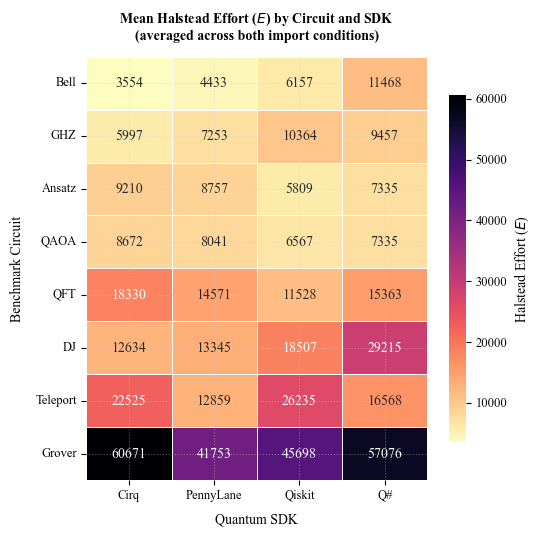

Exported: heatmap_effort_pub.pdf


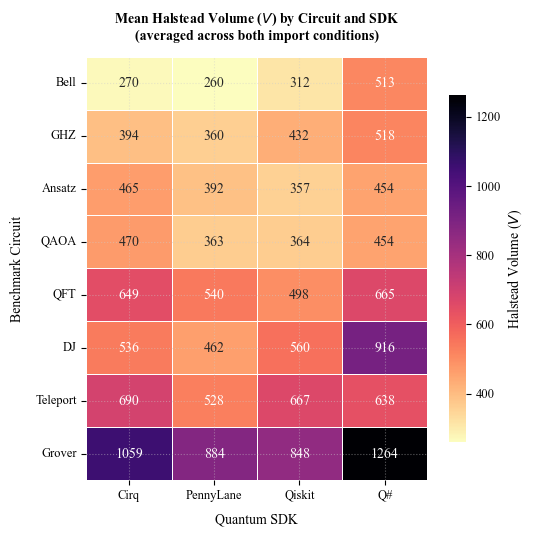

Exported: heatmap_volume_pub.pdf


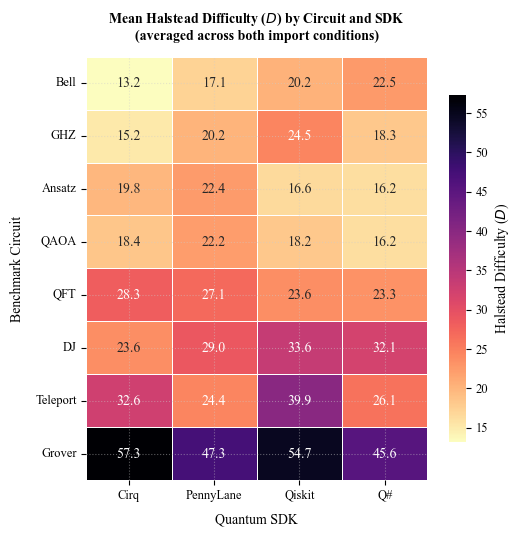

Exported: heatmap_difficulty_pub.pdf


In [5]:
for metric in METRICS:

    # Pivot table:
    #   Rows    → circuits (ordered by CIRCUIT_ORDER)
    #   Columns → SDKs (ordered by SDK_ORDER)
    #   Values  → mean metric value (averaged over both conditions)
    pivot_heat = (
        df.groupby(["circuit", "sdk"])[metric]
        .mean()
        .unstack()[SDK_ORDER]
        .reindex(CIRCUIT_ORDER)
    )

    # Determine numeric formatting for annotations
    # Use one decimal if values are < 100 (e.g., difficulty),
    # otherwise use integer formatting (e.g., effort, volume)
    fmt = ".1f" if pivot_heat.max().max() < 100 else ".0f"

    # Create square figure
    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    # Render heatmap
    sns.heatmap(
        pivot_heat,
        annot=True,
        fmt=fmt,
        cmap="magma_r",
        linewidths=0.6,
        linecolor="white",
        cbar_kws={
            "label":  METRIC_LABELS[metric],
            "shrink": 0.82,
        },
        ax=ax,
    )

    # Title and axis labels
    ax.set_title(
        f"Mean {METRIC_LABELS[metric]} by Circuit and SDK\n"
        "(averaged across both import conditions)",
        fontweight="bold",
        pad=12,
    )
    ax.set_xlabel("Quantum SDK", labelpad=8)
    ax.set_ylabel("Benchmark Circuit", labelpad=8)

    # Keep circuit labels horizontal
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # Export figure
    fig.savefig(f"heatmap_{metric}_pub.pdf", dpi=600, bbox_inches="tight")

    # Display figure
    plt.show()

    # Print export confirmation
    print(f"Exported: heatmap_{metric}_pub.pdf")

# Cell 5 — Inferential Statistics (Repeated-Measures Design)

**Design**  
Fully repeated-measures layout  
- 16 circuit–condition blocks  
- 4 SDKs  
- Within-subject factor: SDK  

---

## Statistical Pipeline

1. **Normality Assessment**  
   Shapiro–Wilk test per SDK group (α = 0.05)

2. **Omnibus Test**  
   - Repeated-measures ANOVA (if all groups normal)  
   - Friedman test (otherwise)

3. **Post-hoc Pairwise Comparisons**  
   - Paired t-test (parametric case)  
   - Wilcoxon signed-rank test (non-parametric case)

4. **Multiple-Comparison Correction**  
   Benjamini–Hochberg FDR (α_FDR = 0.05)

5. **Effect Size Reporting**  
   - Cohen’s d (parametric)  
   - Rank-biserial correlation r (non-parametric)  
     Computed via `pingouin.wilcoxon` (Kerby 2014 formulation)

---

## Output

- `results_summary`  
  Structured list of per-comparison dictionaries  
  Consumed by downstream summary and reporting cells.

---

**Notes**
- All analyses are performed for each metric in `METRICS`.
- Assumption checks precede inferential testing.
- Repeated-measures structure is preserved throughout.

In [6]:
def _magnitude_label(r: float) -> str:
    r = abs(r)
    if r < 0.10: return "Negligible"
    if r < 0.30: return "Small"
    if r < 0.50: return "Medium"
    return "Large"


results_summary = []

for metric in METRICS:
    print("=" * 55)
    print(f"  {metric.upper()}  —  n = 16 blocks per SDK")
    print("=" * 55)

    pivot = df.pivot(index="block", columns="sdk", values=metric)[SDK_ORDER]

    # -----------------------------
    # Normality
    # -----------------------------
    all_normal = True
    for sdk in SDK_ORDER:
        _, p_sw = stats.shapiro(pivot[sdk])
        if p_sw < 0.05:
            all_normal = False

    # -----------------------------
    # Omnibus
    # -----------------------------
    if all_normal:
        aov = pg.rm_anova(
            data=df,
            dv=metric,
            within="sdk",
            subject="block",
            detailed=True,
        )
        omnibus_df = aov.copy()
        omnibus_df = omnibus_df.rename(columns={
            "Source": "Source",
            "F": "F",
            "ddof1": "ddof1",
            "ddof2": "ddof2",
            "p-unc": "p-value",
            "np2": "np2"
        })
        display(omnibus_df)
        omnibus_sig = bool(aov.loc[aov["Source"] == "sdk", "p-unc"].values[0] < 0.05)

    else:
        friedman_stat, p_f = stats.friedmanchisquare(*[pivot[sdk] for sdk in SDK_ORDER])
        friedman_df = pd.DataFrame({
            "Metric": [metric.capitalize()],
            "Friedman chi-squared": [round(friedman_stat, 3)],
            "df": [len(SDK_ORDER) - 1],
            "p-value": [round(p_f, 6)],
            "Significant (p < 0.05)": [p_f < 0.05],
        })
        with pd.option_context("display.max_columns", None, "display.width", 1000):
            display(friedman_df)
        omnibus_sig = p_f < 0.05

    # -----------------------------
    # Pairwise comparisons
    # -----------------------------
    pairs, raw_pvals, effects, tests = [], [], [], []

    for i, sdk_a in enumerate(SDK_ORDER):
        for sdk_b in SDK_ORDER[i + 1:]:
            x = pivot[sdk_a].values
            y = pivot[sdk_b].values

            if all_normal:
                _, p_raw = stats.ttest_rel(x, y)
                effect = float(pg.compute_effsize(x, y, paired=True, eftype="cohen"))
                test_tag = "Paired t-test"
            else:
                res = pg.wilcoxon(x, y, alternative="two-sided")
                p_raw = float(res["p-val"].values[0])
                effect = abs(float(res["RBC"].values[0]))
                test_tag = "Wilcoxon"

            pairs.append(f"{sdk_a} vs {sdk_b}")
            raw_pvals.append(p_raw)
            effects.append(effect)
            tests.append(test_tag)

    reject_bh, pvals_bh = pg.multicomp(raw_pvals, method="fdr_bh")

    for i in range(len(pairs)):
        results_summary.append([
            metric,
            pairs[i],
            tests[i],
            round(effects[i], 4),
            round(raw_pvals[i], 6),
            round(pvals_bh[i], 6),
            bool(reject_bh[i]),
        ])

    posthoc_df = pd.DataFrame({
        "Comparison": pairs,
        "Raw p": np.round(raw_pvals, 6),
        "BH-corrected p": np.round(pvals_bh, 6),
        "Significant (BH α=0.05)": reject_bh,
        "Effect Size (r / d)": np.round(effects, 4),
        "Magnitude": [_magnitude_label(e) for e in effects],
    })

    with pd.option_context("display.max_columns", None, "display.width", 1000):
        display(posthoc_df)

    print()

  EFFORT  —  n = 16 blocks per SDK


,Metric,Friedman chi-squared,df,p-value,Significant (p < 0.05)
0,Effort,5.025,3,0.169976,False


,Comparison,Raw p,BH-corrected p,Significant (BH α=0.05),Effect Size (r / d),Magnitude
0,Cirq vs PennyLane,0.143860,0.287720,False,0.4265,Medium
1,Cirq vs Qiskit,0.781952,0.820892,False,0.0882,Negligible
2,Cirq vs Q#,0.820892,0.820892,False,0.0735,Negligible
3,PennyLane vs Qiskit,0.322510,0.483765,False,0.2941,Small
4,PennyLane vs Q#,0.005157,0.030945,True,0.7647,Large
5,Qiskit vs Q#,0.065399,0.196198,False,0.5294,Large



  VOLUME  —  n = 16 blocks per SDK


,Metric,Friedman chi-squared,df,p-value,Significant (p < 0.05)
0,Volume,26.175,3,0.000009,True


,Comparison,Raw p,BH-corrected p,Significant (BH α=0.05),Effect Size (r / d),Magnitude
0,Cirq vs PennyLane,0.000031,0.000092,True,1.0000,Large
1,Cirq vs Qiskit,0.050659,0.060791,False,0.5588,Large
2,Cirq vs Q#,0.021393,0.032089,True,0.6471,Large
3,PennyLane vs Qiskit,0.129730,0.129730,False,0.4412,Medium
4,PennyLane vs Q#,0.000031,0.000092,True,1.0000,Large
5,Qiskit vs Q#,0.000214,0.000427,True,0.9412,Large



  DIFFICULTY  —  n = 16 blocks per SDK


,Metric,Friedman chi-squared,df,p-value,Significant (p < 0.05)
0,Difficulty,3.975,3,0.264176,False


,Comparison,Raw p,BH-corrected p,Significant (BH α=0.05),Effect Size (r / d),Magnitude
0,Cirq vs PennyLane,0.820892,0.820892,False,0.0735,Negligible
1,Cirq vs Qiskit,0.224229,0.595703,False,0.3529,Medium
2,Cirq vs Q#,0.668549,0.802258,False,0.1324,Small
3,PennyLane vs Qiskit,0.528168,0.792252,False,0.1912,Small
4,PennyLane vs Q#,0.297852,0.595703,False,0.3088,Medium
5,Qiskit vs Q#,0.065399,0.392395,False,0.5294,Large


# Cell 6 — Import Condition Analysis

**Design**  
Paired Wilcoxon signed-rank test  
- n = 32 matched pairs  
- Each pair = one circuit–SDK combination  
- Comparison: With Import vs Without Import  

---

## Statistical Details

- Non-parametric paired test  
- Effect size: Rank-biserial correlation (r)  
  Computed via `pingouin.wilcoxon` (Kerby 2014 formulation)

---

## Outputs

- `import_df`  
  Summary table of test statistics, p-values, effect sizes, and percentage differences.

- SDK-level breakdown  
  Difficulty sensitivity to import removal per platform.

---

**Notes**
- Matching is strictly within identical circuit–SDK pairs.
- All three metrics in `METRICS` are evaluated.
- No multiple-comparison correction required (three predefined tests).

In [7]:
import_results = []

for metric in METRICS:

    print(f"\n{'─' * 50}")
    print(f"  Metric: {metric.upper()}")
    print(f"{'─' * 50}")

    # -------------------------------------------------------------------------
    # Extract matched subsets and ensure identical ordering
    # -------------------------------------------------------------------------
    with_df = (
        df[df["dataset"] == "With import"]
        .sort_values(["circuit", "sdk"])
        .reset_index(drop=True)
    )

    without_df = (
        df[df["dataset"] == "Without import"]
        .sort_values(["circuit", "sdk"])
        .reset_index(drop=True)
    )

    # Validate row-level alignment
    assert (
        list(with_df["circuit"] + with_df["sdk"]) ==
        list(without_df["circuit"] + without_df["sdk"])
    ), "Row alignment mismatch between With Import and Without Import subsets."

    x = with_df[metric].values       # With Import condition
    y = without_df[metric].values    # Without Import condition

    # -------------------------------------------------------------------------
    # Wilcoxon signed-rank test (two-sided)
    # -------------------------------------------------------------------------
    res   = pg.wilcoxon(x, y, alternative="two-sided")
    W_val = float(res["W-val"].values[0])
    p_val = float(res["p-val"].values[0])
    rbc   = abs(float(res["RBC"].values[0]))  # Rank-biserial correlation

    # Percentage difference relative to Without Import baseline
    diff_pct  = (x.mean() - y.mean()) / y.mean() * 100
    direction = (
        "With Import > Without Import"
        if x.mean() > y.mean()
        else "Without Import > With Import"
    )
    sig_label = "Yes" if p_val < 0.05 else "No"

    print(f"  W = {W_val:.1f},  p = {p_val:.4f},  r = {rbc:.4f}  [{sig_label}]")
    print(f"  Mean Δ = {diff_pct:+.2f}%  ({direction})")

    import_results.append([
        metric.capitalize(),
        round(W_val, 1),
        round(p_val, 4),
        round(rbc, 4),
        f"{diff_pct:+.2f}%",
        direction,
        sig_label,
    ])


# -----------------------------------------------------------------------------
# SDK-Level Sensitivity Analysis (Difficulty Metric)
# -----------------------------------------------------------------------------
# Computes percentage increase in difficulty when import statements are removed
# -----------------------------------------------------------------------------

print(f"\n{'─' * 55}")
print("  SDK-Level Import Sensitivity — Difficulty (Δ%)")
print(f"{'─' * 55}")

for sdk in SDK_ORDER:

    d_with = df[
        (df["sdk"] == sdk) &
        (df["dataset"] == "With import")
    ]["difficulty"].mean()

    d_without = df[
        (df["sdk"] == sdk) &
        (df["dataset"] == "Without import")
    ]["difficulty"].mean()

    pct_change = (d_without - d_with) / d_with * 100

    print(
        f"  {sdk:<12}  Without import is {pct_change:+.1f}% relative to With import"
    )


# -----------------------------------------------------------------------------
# Summary Table
# -----------------------------------------------------------------------------

print()

import_df = pd.DataFrame(
    import_results,
    columns=[
        "Metric",
        "W",
        "p-value",
        "r (RBC)",
        "Mean Δ%",
        "Direction",
        "Significant",
    ],
)

display(import_df)


──────────────────────────────────────────────────
  Metric: EFFORT
──────────────────────────────────────────────────
  W = 166.0,  p = 0.0683,  r = 0.3712  [No]
  Mean Δ = -8.84%  (Without Import > With Import)

──────────────────────────────────────────────────
  Metric: VOLUME
──────────────────────────────────────────────────
  W = 0.0,  p = 0.0000,  r = 1.0000  [Yes]
  Mean Δ = +13.78%  (With Import > Without Import)

──────────────────────────────────────────────────
  Metric: DIFFICULTY
──────────────────────────────────────────────────
  W = 10.0,  p = 0.0000,  r = 0.9621  [Yes]
  Mean Δ = -18.26%  (Without Import > With Import)

───────────────────────────────────────────────────────
  SDK-Level Import Sensitivity — Difficulty (Δ%)
───────────────────────────────────────────────────────
  Cirq          Without import is +5.6% relative to With import
  PennyLane     Without import is +16.2% relative to With import
  Qiskit        Without import is +55.8% relative to With impo

,Metric,W,p-value,r (RBC),Mean Δ%,Direction,Significant
0,Effort,166.0,0.0683,0.3712,-8.84%,Without Import > With Import,No
1,Volume,0.0,0.0000,1.0000,+13.78%,With Import > Without Import,Yes
2,Difficulty,10.0,0.0000,0.9621,-18.26%,Without Import > With Import,Yes


# Cell 7 — Post-hoc Effect Size Summary

**Purpose**  
Aggregate all pairwise comparison results into a consolidated summary table with standardised effect size magnitudes.

---

## Content

- Metric name  
- SDK pair comparison  
- Test type (parametric / non-parametric)  
- Raw p-value  
- FDR-adjusted p-value  
- Effect size (Cohen’s d or rank-biserial r)  
- Magnitude classification  

---

## Effect Size Interpretation

Magnitude thresholds:

- Negligible  
- Small  
- Medium  
- Large  

Rank-biserial thresholds follow Cohen (1988) benchmarks adapted via Kerby (2014).

---

**Notes**
- Source data derived from `results_summary` generated in Cell 5.
- Only corrected p-values determine significance status.
- Table structure is standardised for reporting consistency.

In [8]:
summary_df = pd.DataFrame(
    results_summary,
    columns=[
        "Metric",
        "Comparison",
        "Test",
        "Effect Size (r / d)",
        "Raw p",
        "BH-corrected p",
        "Significant (BH α=0.05)",
    ],
)

summary_df["Metric"] = pd.Categorical(
    summary_df["Metric"],
    categories=METRICS,
    ordered=True,
)

summary_df = (
    summary_df
    .sort_values(["Metric", "Comparison"])
    .reset_index(drop=True)
)

display(summary_df.round(6))

,Metric,Comparison,Test,Effect Size (r / d),Raw p,BH-corrected p,Significant (BH α=0.05)
0,effort,Cirq vs PennyLane,Wilcoxon,0.4265,0.143860,0.287720,False
1,effort,Cirq vs Q#,Wilcoxon,0.0735,0.820892,0.820892,False
2,effort,Cirq vs Qiskit,Wilcoxon,0.0882,0.781952,0.820892,False
3,effort,PennyLane vs Q#,Wilcoxon,0.7647,0.005157,0.030945,True
4,effort,PennyLane vs Qiskit,Wilcoxon,0.2941,0.322510,0.483765,False
5,effort,Qiskit vs Q#,Wilcoxon,0.5294,0.065399,0.196198,False
6,volume,Cirq vs PennyLane,Wilcoxon,1.0000,0.000031,0.000092,True
7,volume,Cirq vs Q#,Wilcoxon,0.6471,0.021393,0.032089,True
8,volume,Cirq vs Qiskit,Wilcoxon,0.5588,0.050659,0.060791,False
9,volume,PennyLane vs Q#,Wilcoxon,1.0000,0.000031,0.000092,True


Exported: effort_by_circuit.pdf


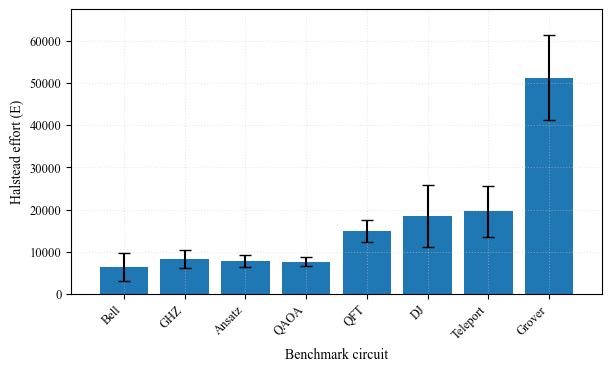

In [ ]:
# -----------------------------------------------------------------------------
# Mean Halstead Effort by Circuit (±1 SD)
# Aggregated across all SDKs and both import conditions (n = 8 per circuit)
# -----------------------------------------------------------------------------

import os
import matplotlib.pyplot as plt



# Aggregate mean and SD
effort_stats = (
    df.groupby("circuit")["effort"]
    .agg(["mean", "std"])
    .reindex(CIRCUIT_ORDER)
)

fig, ax = plt.subplots(figsize=(6.0, 3.6), layout="constrained")

ax.bar(
    effort_stats.index,
    effort_stats["mean"],
    yerr=effort_stats["std"],
    capsize=4,
)

ax.set_xlabel("Benchmark circuit")
ax.set_ylabel("Halstead effort (E)")


plt.setp(ax.get_xticklabels(), rotation=45, ha="right")


ax.margins(x=0.06, y=0.1)


ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)


for spine in ["top", "bottom", "left", "right"]:
    ax.spines[spine].set_color("black")
    ax.spines[spine].set_linewidth(0.8)

# Save the final figure
fig.savefig("effort_by_circuit.pdf", dpi=600)
print("Exported: effort_by_circuit.pdf")

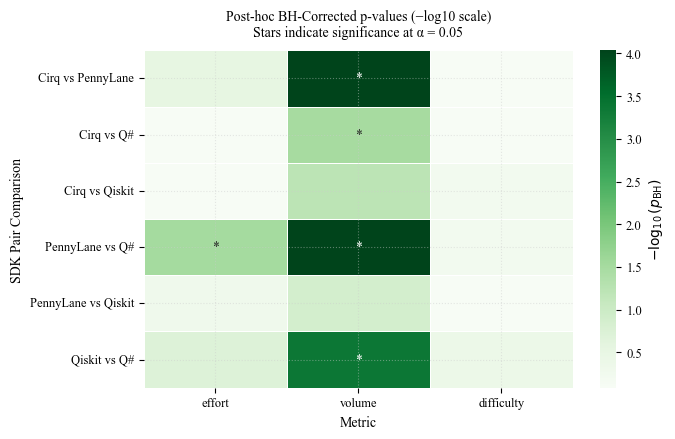

Exported: posthoc_heatmap.pdf


In [10]:
# -----------------------------------------------------------------------------
# Post-hoc BH-corrected p-value Heatmap (−log10 scale)
# -----------------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("figures", exist_ok=True)

posthoc_df = pd.DataFrame(
    results_summary,
    columns=[
        "Metric",
        "Comparison",
        "Test",
        "Effect Size (r / d)",
        "Raw p",
        "BH-corrected p",
        "Significant (BH α=0.05)",
    ],
)

posthoc_df["Metric"] = pd.Categorical(
    posthoc_df["Metric"],
    categories=METRICS,
    ordered=True,
)

posthoc_df = posthoc_df.sort_values(["Comparison", "Metric"])

# Compute −log10(BH p)
posthoc_df["-log10(p)"] = -np.log10(posthoc_df["BH-corrected p"])

# Single pivot to ensure identical ordering
heatmap_df = posthoc_df.pivot(
    index="Comparison",
    columns="Metric",
    values="-log10(p)",
)

sig_df = posthoc_df.pivot(
    index="Comparison",
    columns="Metric",
    values="Significant (BH α=0.05)",
)

# Build annotation DataFrame with identical index/columns
annot_df = sig_df.replace({True: "*", False: ""})

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.heatmap(
    heatmap_df,
    annot=annot_df,
    fmt="",
    cmap="Greens",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": r"$-\log_{10}(p_{\mathrm{BH}})$"},
    ax=ax,
)

ax.set_title(
    "Post-hoc BH-Corrected p-values (−log10 scale)\n"
    "Stars indicate significance at α = 0.05",
    pad=10,
)

ax.set_xlabel("Metric")
ax.set_ylabel("SDK Pair Comparison")

fig.tight_layout()
fig.savefig("posthoc_heatmap.pdf", dpi=600, bbox_inches="tight")

plt.show()
print("Exported: posthoc_heatmap.pdf")

In [11]:
exports = {
    "desc_overall.csv":         (desc_overall,  True),
    "desc_by_condition.csv":    (desc_cond,     True),
    "desc_by_circuit.csv":      (desc_circuit,  True),
    "posthoc_effect_sizes.csv": (summary_df,    False),
    "rq3_import_condition.csv": (import_df,     False),
}

for filename, (dataframe, include_index) in exports.items():
    dataframe.to_csv(filename, index=include_index)
    print(f"Saved: {filename}")

print("\nAll supplementary data files successfully exported.")

Saved: desc_overall.csv
Saved: desc_by_condition.csv
Saved: desc_by_circuit.csv
Saved: posthoc_effect_sizes.csv
Saved: rq3_import_condition.csv

All supplementary data files successfully exported.


In [12]:
print(posthoc_df["Significant (BH α=0.05)"].unique())
print(posthoc_df["Significant (BH α=0.05)"].dtype)

[False  True]
bool
